In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import pandas as pd

df = pd.read_csv('spam.csv', encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
## data cleaning:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [ ]:
## drop Unnamed 2,3 and 4 column becauase they contains huge null values:

df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df.sample(8)

,v1,v2
254,ham,"I'm back, lemme know when you're ready"
949,ham,Is that what time you want me to come?
2445,ham,The guy (kadeem) hasn't been selling since the...
733,ham,Even u dont get in trouble while convincing..j...
1663,ham,S but mostly not like that.
2021,ham,"I don't have anybody's number, I still haven't..."
3413,ham,No pic. Please re-send.
5200,spam,Call Germany for only 1 pence per minute! Call...


In [ ]:
## renaming the columns:
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(9)

,target,text
991,ham,Hi im having the most relaxing time ever! we h...
2472,spam,Final Chance! Claim ur å£150 worth of discount...
1615,ham,Mm i had my food da from out
2855,ham,"Japanese Proverb: If one Can do it, U too Can ..."
5360,ham,"Hey, iouri gave me your number, I'm wylie, rya..."
741,ham,Do well :)all will for little time. Thing of g...
3407,spam,Do you want a New Nokia 3510i colour phone Del...
5333,ham,Neither [in sterm voice] - i'm studying. All f...
2763,ham,"Say this slowly.? GOD,I LOVE YOU &amp; I NEED ..."


In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()


In [ ]:
df['target']=encoder.fit_transform(df['target'])

In [ ]:
df.sample(5)

,target,text
5231,0,I realise you are a busy guy and i'm trying no...
2629,0,Hey there! Glad u r better now. I hear u treat...
1894,1,"FreeMsg Hey U, i just got 1 of these video/pic..."
2684,0,Yupz... I've oredi booked slots 4 my weekends ...
1152,0,Ok i go change also...


In [ ]:
# missing values:
df.isnull().sum()

,0
target,0
text,0


In [ ]:
# check duplicate values:
df.duplicated().sum()

np.int64(403)

In [ ]:
# so our dataset has 403 duplicate values  so drop that:
df=df.drop_duplicates(keep='first')
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(5169, 2)

In [ ]:
## EDA:
df.head()

df['target'].value_counts()

,count
target,
0,4516
1,653


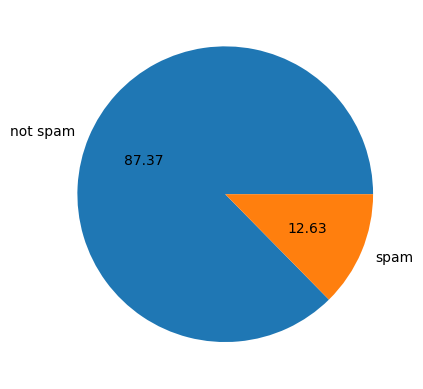

In [ ]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=["not spam","spam"],autopct="%0.2f")
plt.show()

In [ ]:
# after anaysis this pie chart we can clearly say that our data is highly unbalanced



In [ ]:
import nltk
!pip install nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
df['num_characters']=df["text"].apply(len)
df.sample()

,target,text,num_characters
5570,0,The guy did some bitching but I acted like i'd...,125


In [ ]:
##num of words:
df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))

In [ ]:
df[['text', 'num_words']].head()

,text,num_words
0,"Go until jurong point, crazy.. Available only ...",24
1,Ok lar... Joking wif u oni...,8
2,Free entry in 2 a wkly comp to win FA Cup fina...,37
3,U dun say so early hor... U c already then say...,13
4,"Nah I don't think he goes to usf, he lives aro...",15


In [ ]:
### number of sentences

df['num_sentences']=df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))


In [ ]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [ ]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [ ]:
df[df['target']==0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [ ]:
#spam
df[df['target']==1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [ ]:
import seaborn as sns

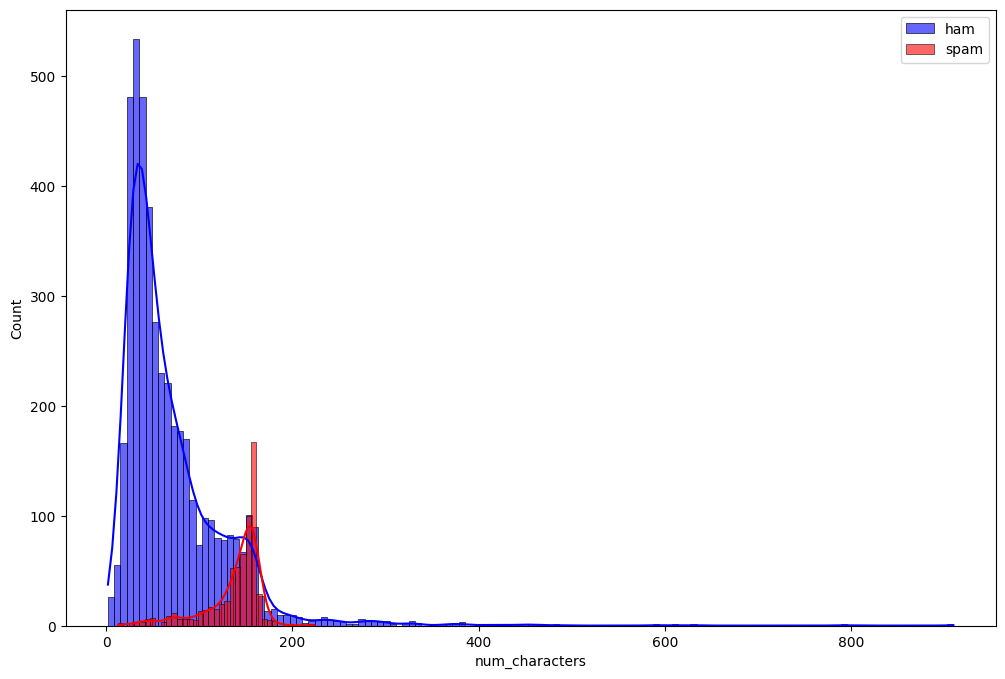

In [ ]:
plt.figure(figsize=(12,8))

sns.histplot(df[df['target'] == 0]['num_characters'], color='blue', label='ham', kde=True, alpha=0.6)
sns.histplot(df[df['target'] == 1]['num_characters'], color='red', label='spam', kde=True, alpha=0.6)

plt.legend()
plt.show()

# insights from this histogram

- Most ham messages are short, usually between 20 and 100 characters.

- Spam messages are generally longer, mostly around 100 to 180 characters.

- Ham messages have more variation and some very long outliers.

- Spam messages are more concentrated around a certain range.

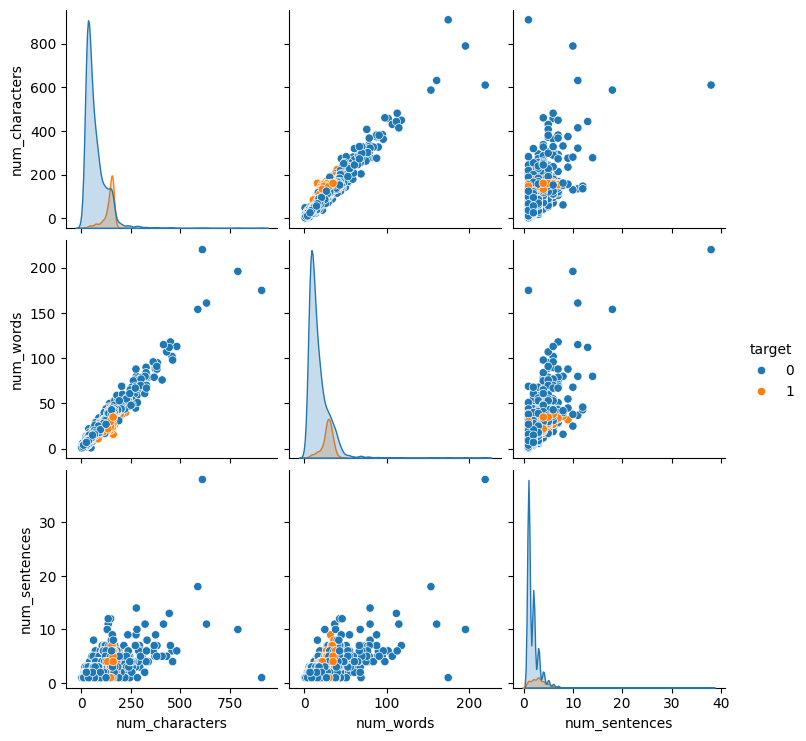

In [ ]:
sns.pairplot(df,hue='target')
plt.show()

In [ ]:
df[['target', 'num_characters', 'num_words', 'num_sentences']].corr()

,target,num_characters,num_words,num_sentences
target,1.000000,0.384717,0.262912,0.263939
num_characters,0.384717,1.000000,0.965760,0.624139
num_words,0.262912,0.965760,1.000000,0.679971
num_sentences,0.263939,0.624139,0.679971,1.000000


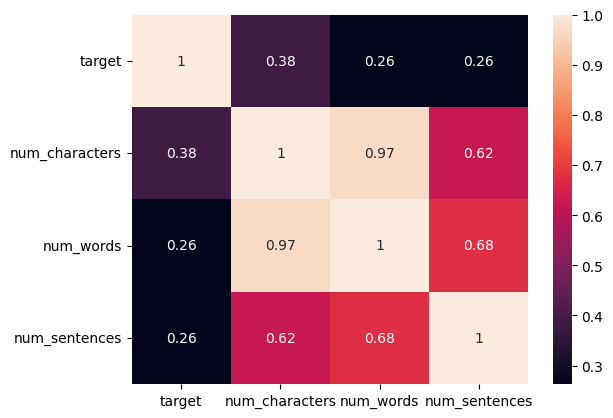

In [ ]:
sns.heatmap(df[['target', 'num_characters', 'num_words', 'num_sentences']].corr(), annot=True)
plt.show()

In [ ]:
### 3.data preprocessing:

##check contains emojis or not
import re

emoji_pattern = re.compile("["
    u"\U0001F600-\U0001F64F"  # emoticons
    u"\U0001F300-\U0001F5FF"  # symbols & pictographs
    u"\U0001F680-\U0001F6FF"  # transport & map symbols
    u"\U0001F1E0-\U0001F1FF"  # flags
    u"\U00002702-\U000027B0"
    u"\U000024C2-\U0001F251"
    "]+", flags=re.UNICODE)

df['has_emoji'] = df['text'].apply(lambda x: bool(emoji_pattern.search(x)))
df['has_emoji'].value_counts()

,count
has_emoji,
False,5169


In [ ]:
## now check emotions in our datase :) , :-(
emoticon_pattern = r'(:\)|:-\)|:\(|:-\(|:D|XD|<3|;\)|:-P|:\*)'


df['text'].str.contains(emoticon_pattern, regex=True, na=False).value_counts()

/tmp/ipykernel_10537/1478588730.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['text'].str.contains(emoticon_pattern, regex=True, na=False).value_counts()


,count
text,
False,4853
True,316


In [ ]:
## so our data has emotions for first convert into text then we will apply other
import re

def convert_emoticons(text):
    emoticon_dict = {
        ':)': 'smile',
        ':-)': 'smile',
        ':(': 'sad',
        ':-(': 'sad',
        ':D': 'laugh',
        'XD': 'laugh',
        '<3': 'love',
        ';)': 'wink',
        ':-P': 'playful',
        ':*': 'kiss'
    }

    for emoticon, meaning in emoticon_dict.items():
        text = text.replace(emoticon, meaning)

    return text

df['transformed_text'] = df['text'].apply(convert_emoticons)

### datapreprocessing
- removing emojis and emoctions ->done
- lowercase and remove extra space

- tokenization

- remove special caracters

- remove stop words and punctuations

- stemming



In [ ]:
### removing stop words:
import nltk

nltk.download('stopwords')
from nltk.corpus import stopwords
stopwords.words('english')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [ ]:
import  string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [ ]:
### stemming:
from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()
ps.stem('playing')
ps.stem('wanted')

'want'

In [ ]:
from nltk.corpus import stopwords
import string
import nltk
import re

stop_words = set(stopwords.words('english'))

def transform_text(text):

    # If text is already a list, convert it to string
    if isinstance(text, list):
        text = " ".join(text)

    text = text.lower()  # lowercase
    text = re.sub(r'\s+', ' ', text)  # remove extra spaces
    text = nltk.word_tokenize(text)  # tokenize

    y = []
    for word in text:
        if word.isalnum():
            y.append(word)

    text = y
    y = []
## remove stopwords:
    for word in text:
        if word not in stop_words and word not in string.punctuation:
            y.append(word)

    text = y
    y = []
    for word in text:
        y.append(ps.stem(word))

    return " ".join(y)

In [ ]:
df['transformed_text']=df['text'].apply(transform_text)
df=df.drop(columns=['has_emoji'])
df.sample(8)

,target,text,num_characters,num_words,num_sentences,transformed_text
2941,0,"Hello. No news on job, they are making me wait...",142,35,4,hello news job make wait fifth week yeah im wo...
4426,0,So what did the bank say about the money?,41,10,1,bank say money
1382,0,Its ok my arm is feeling weak cuz i got a shot...,72,18,1,ok arm feel weak cuz got shot go anoth time
3620,0,That means from february to april i'll be gett...,190,40,1,mean februari april get place stay hustl back ...
1327,1,Ur balance is now å£500. Ur next question is: ...,126,32,4,ur balanc ur next question sang girl 80 2 answ...
3800,0,"It's ok, at least armand's still around",39,10,1,ok least armand still around
851,0,"I am real, baby! I want to bring out your inne...",58,15,2,real babi want bring inner tigress
1643,0,U WILL SWITCH YOUR FONE ON DAMMIT!!,35,9,2,u switch fone dammit


In [ ]:
transform_text(convert_emoticons("this is% the alpha numerical data $)to present * & % :); hii how are you and can i make multi million dollor "))

'alpha numer data present smile hii make multi million dollor'

In [ ]:
df["text"][70]

'Wah lucky man... Then can save money... Hee...'

## A word cloud is a visual representation of words where the most frequent words appear bigger and bolder.

In [ ]:
from wordcloud import WordCloud
wc=WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [ ]:
spam_wc=wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))


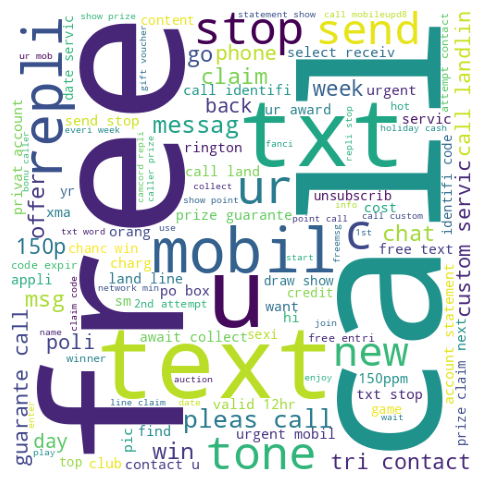

In [ ]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)
plt.axis('off')
plt.show()

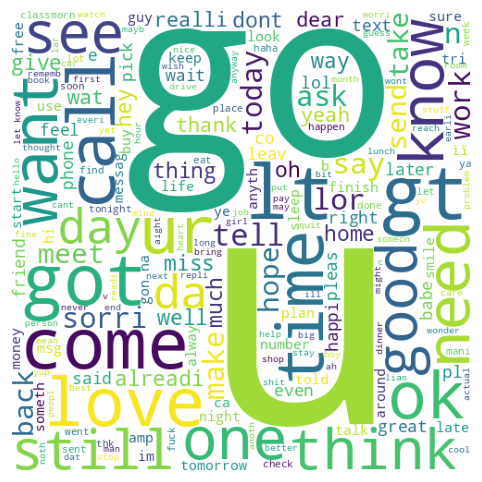

In [ ]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=' '))

plt.figure(figsize=(12,6))
plt.imshow(ham_wc)
plt.axis('off')
plt.show()

In [ ]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [ ]:
spam_corpus=[]
for msg in df[df['target']==1]['transformed_text'].tolist():
  for word in msg.split():
    spam_corpus.append(word)

spam_corpus

['free',
 'entri',
 '2',
 'wkli',
 'comp',
 'win',
 'fa',
 'cup',
 'final',
 'tkt',
 '21st',
 'may',
 'text',
 'fa',
 '87121',
 'receiv',
 'entri',
 'question',
 'std',
 'txt',
 'rate',
 'c',
 'appli',
 '08452810075over18',
 'freemsg',
 'hey',
 'darl',
 '3',
 'week',
 'word',
 'back',
 'like',
 'fun',
 'still',
 'tb',
 'ok',
 'xxx',
 'std',
 'chg',
 'send',
 'rcv',
 'winner',
 'valu',
 'network',
 'custom',
 'select',
 'receivea',
 'prize',
 'reward',
 'claim',
 'call',
 'claim',
 'code',
 'kl341',
 'valid',
 '12',
 'hour',
 'mobil',
 '11',
 'month',
 'u',
 'r',
 'entitl',
 'updat',
 'latest',
 'colour',
 'mobil',
 'camera',
 'free',
 'call',
 'mobil',
 'updat',
 'co',
 'free',
 '08002986030',
 'six',
 'chanc',
 'win',
 'cash',
 '100',
 'pound',
 'txt',
 'csh11',
 'send',
 'cost',
 '6day',
 'tsandc',
 'appli',
 'repli',
 'hl',
 '4',
 'info',
 'urgent',
 '1',
 'week',
 'free',
 'membership',
 'prize',
 'jackpot',
 'txt',
 'word',
 'claim',
 '81010',
 'c',
 'lccltd',
 'pobox',
 '4403ldnw

In [ ]:
print(len(spam_corpus))  # our spam corpus has 9939 words


## we know that spam_corpus has around 9k words so if we want some top spam words so we use Counter

from collections import Counter
Counter(spam_corpus).most_common(45)

9939


[('call', 320),
 ('free', 191),
 ('2', 155),
 ('txt', 141),
 ('text', 122),
 ('u', 119),
 ('ur', 119),
 ('mobil', 114),
 ('stop', 104),
 ('repli', 103),
 ('claim', 98),
 ('4', 97),
 ('prize', 82),
 ('get', 74),
 ('new', 64),
 ('servic', 64),
 ('tone', 63),
 ('send', 60),
 ('urgent', 57),
 ('nokia', 57),
 ('contact', 56),
 ('award', 55),
 ('phone', 52),
 ('cash', 51),
 ('pleas', 51),
 ('week', 49),
 ('win', 48),
 ('c', 45),
 ('collect', 45),
 ('min', 45),
 ('custom', 42),
 ('messag', 42),
 ('guarante', 42),
 ('per', 41),
 ('chat', 38),
 ('tri', 37),
 ('msg', 35),
 ('draw', 35),
 ('number', 35),
 ('cs', 35),
 ('show', 33),
 ('today', 33),
 ('offer', 33),
 ('line', 33),
 ('go', 32)]

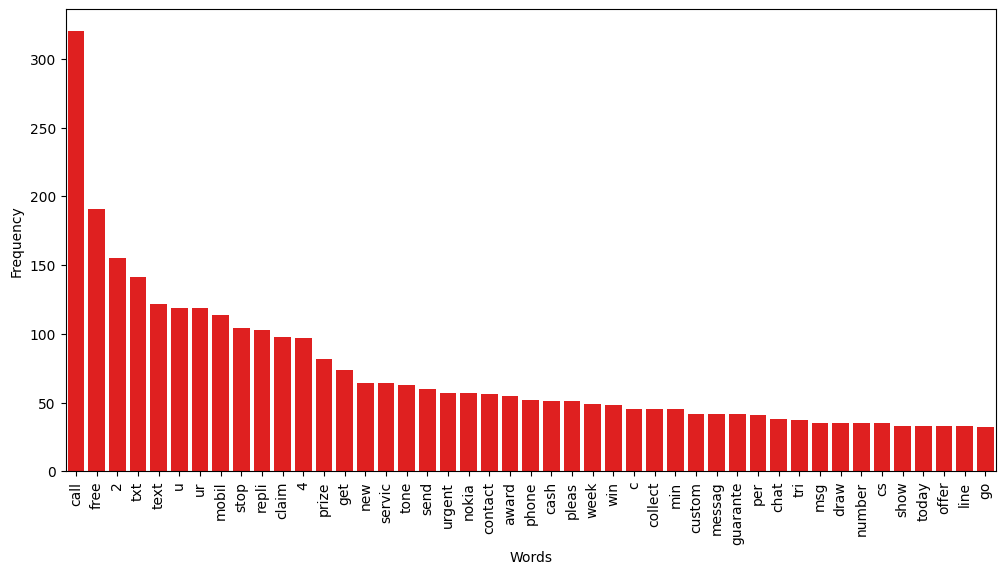

In [ ]:
most_common_df = pd.DataFrame(Counter(spam_corpus).most_common(45))

plt.figure(figsize=(12,6))
sns.barplot(x=most_common_df[0], y=most_common_df[1], color='red')

plt.xticks(rotation='vertical')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.show()

In [ ]:
ham_corpus=[]
for msg in df[df['target']==0]['transformed_text'].tolist():
  for word in msg.split():
    ham_corpus.append(word)

ham_corpus

['go',
 'jurong',
 'point',
 'crazi',
 'avail',
 'bugi',
 'n',
 'great',
 'world',
 'la',
 'e',
 'buffet',
 'cine',
 'got',
 'amor',
 'wat',
 'ok',
 'lar',
 'joke',
 'wif',
 'u',
 'oni',
 'u',
 'dun',
 'say',
 'earli',
 'hor',
 'u',
 'c',
 'alreadi',
 'say',
 'nah',
 'think',
 'goe',
 'usf',
 'live',
 'around',
 'though',
 'even',
 'brother',
 'like',
 'speak',
 'treat',
 'like',
 'aid',
 'patent',
 'per',
 'request',
 'mell',
 'oru',
 'minnaminungint',
 'nurungu',
 'vettam',
 'set',
 'callertun',
 'caller',
 'press',
 '9',
 'copi',
 'friend',
 'callertun',
 'gon',
 'na',
 'home',
 'soon',
 'want',
 'talk',
 'stuff',
 'anymor',
 'tonight',
 'k',
 'cri',
 'enough',
 'today',
 'search',
 'right',
 'word',
 'thank',
 'breather',
 'promis',
 'wont',
 'take',
 'help',
 'grant',
 'fulfil',
 'promis',
 'wonder',
 'bless',
 'time',
 'date',
 'sunday',
 'oh',
 'k',
 'watch',
 'eh',
 'u',
 'rememb',
 '2',
 'spell',
 'name',
 'ye',
 'v',
 'naughti',
 'make',
 'v',
 'wet',
 'fine',
 'thatåõ',
 'wa

In [ ]:
len(ham_corpus)

35404

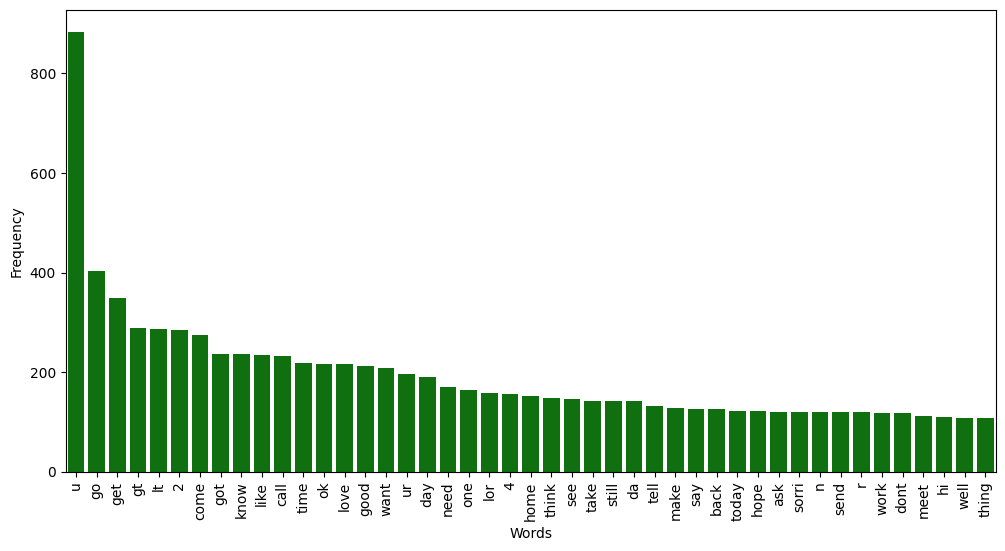

In [ ]:
most_common_df = pd.DataFrame(Counter(ham_corpus).most_common(45))

plt.figure(figsize=(12,6))
sns.barplot(x=most_common_df[0], y=most_common_df[1], color='green')

plt.xticks(rotation='vertical')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.show()

## Model Training:

In [ ]:
### Model training:

## first we convert the text into number or vector so we apply vectorization:

from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv=CountVectorizer()
tfidf=TfidfVectorizer()

In [ ]:
X=tfidf.fit_transform(df['transformed_text']).toarray()

y=df['target'].values
y

array([0, 0, 1, ..., 0, 0, 0])

In [ ]:
X.shape, y.shape

((5169, 6708), (5169,))

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=43)

In [ ]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [ ]:
gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()

In [ ]:
gnb.fit(X_train,y_train)
y_pred1=gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8626692456479691
[[769 126]
 [ 16 123]]
0.4939759036144578


In [ ]:
mnb.fit(X_train,y_train)
y_pred2=mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9622823984526112
[[895   0]
 [ 39 100]]
1.0


In [ ]:
bnb.fit(X_train,y_train)
y_pred2=bnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9613152804642167
[[888   7]
 [ 33 106]]
0.9380530973451328


In [ ]:
### we choose ifidf and mnb  ifidf->MNB:
# but we also explore some other models and compare their result and then we choose best one


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier


In [ ]:
svc=SVC(kernel='sigmoid',gamma=1.0)
knc=KNeighborsClassifier()
mnb=MultinomialNB()
dtc=DecisionTreeClassifier(max_depth=5)
lrc=LogisticRegression(solver='liblinear',penalty='l1')
rfc=RandomForestClassifier(n_estimators=50, random_state=43)
abc=AdaBoostClassifier(n_estimators=50,random_state=43)
bc=BaggingClassifier(n_estimators=50,random_state=43)
etc=ExtraTreesClassifier(n_estimators=50,random_state=43)
xgb=XGBClassifier(n_estimators=50,random_state=43)
gbdt=GradientBoostingClassifier(n_estimators=50,random_state=43)


In [ ]:
clfs={
    "SVC":svc,
    "KN":knc,
    "NB":mnb,
    "DT":dtc,
    "LR":lrc,
    "RF":rfc,
    "AdaBoost":abc,
    "BgC":bc,
    "ETC":etc,
    "xgb":xgb,
    "GBDT":gbdt
}




In [ ]:
 from sklearn.metrics import accuracy_score, precision_score

def train_classifier(clf,X_train,y_train,X_test,y_test):
  clf.fit(X_train,y_train)
  y_pred=clf.predict(X_test)
  accuracy=accuracy_score(y_test,y_pred)
  precision=precision_score(y_test,y_pred)
  return accuracy,precision



In [ ]:
accuracy_scores = []
precision_scores = []

for name, clf in clfs.items():
    current_accuracy, current_precision = train_classifier(clf, X_train, y_train, X_test, y_test)

    print("For:", name)
    print(f"Accuracy is {current_accuracy}")
    print(f"Precision is {current_precision} \n ")

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For: SVC
Accuracy is 0.9661508704061895
Precision is 0.9814814814814815 
 
For: KN
Accuracy is 0.8984526112185687
Precision is 1.0 
 
For: NB
Accuracy is 0.9622823984526112
Precision is 1.0 
 
For: DT
Accuracy is 0.9177949709864603
Precision is 0.7647058823529411 
 
For: LR
Accuracy is 0.9439071566731141
Precision is 0.945054945054945 
 
For: RF
Accuracy is 0.9613152804642167
Precision is 0.9805825242718447 
 
For: AdaBoost
Accuracy is 0.9187620889748549
Precision is 0.8021978021978022 
 
For: BgC
Accuracy is 0.9410058027079303
Precision is 0.8046875 
 
For: ETC
Accuracy is 0.9671179883945842
Precision is 0.972972972972973 
 
For: xgb
Accuracy is 0.9613152804642167
Precision is 0.9380530973451328 
 
For: GBDT
Accuracy is 0.9361702127659575
Precision is 0.8762886597938144 
 


In [ ]:
performance_df=pd.DataFrame({"Algorithm":clfs.keys(),"Accuracy":accuracy_scores,"Precision":precision_scores})

performance_df=performance_df.sort_values(by=["Precision","Accuracy"],ascending=False)
performance_df

,Algorithm,Accuracy,Precision
2,NB,0.962282,1.000000
1,KN,0.898453,1.000000
0,SVC,0.966151,0.981481
5,RF,0.961315,0.980583
8,ETC,0.967118,0.972973
4,LR,0.943907,0.945055
9,xgb,0.961315,0.938053
10,GBDT,0.936170,0.876289
7,BgC,0.941006,0.804688
6,AdaBoost,0.918762,0.802198


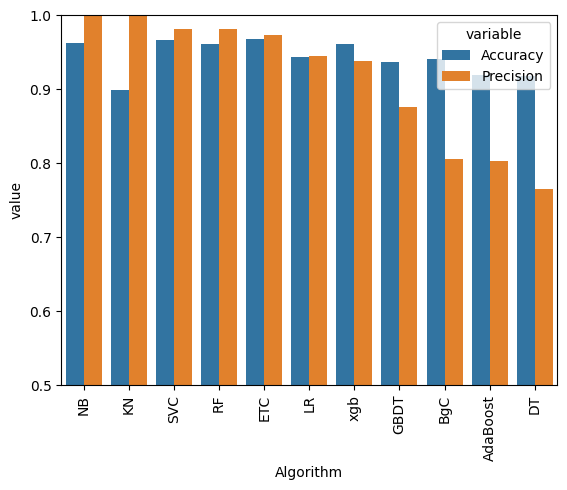

In [ ]:
performance_df_melted = performance_df.melt(id_vars='Algorithm')


sns.barplot(
    x='Algorithm',
    y='value',
    hue='variable',
    data=performance_df_melted
)

plt.ylim(0.5, 1.0)
plt.xticks(rotation='vertical')
plt.show()

**Improve model->**

In [ ]:
## model improve
##update tfit:
tfidf = TfidfVectorizer(max_features=3000)
X=tfidf.fit_transform(df['transformed_text']).toarray()

y = df['target'].values


from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=3)

accuracy_scores_3000 = []
precision_scores_3000 = []
for name, clf in clfs.items():
    curr_acc, curr_prec = train_classifier(clf, X_train, y_train, X_test, y_test)
    accuracy_scores_3000.append(curr_acc)
    precision_scores_3000.append(curr_prec)

In [ ]:
mnb.fit(X_train,y_train)
y_pred2=mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.97678916827853
[[895   0]
 [ 24 115]]
1.0


In [ ]:
# Create the new dataframe
temp_df = pd.DataFrame({
    'Algorithm': clfs.keys(),
    'Accuracy_3000': accuracy_scores_3000,
    'Precision_3000': precision_scores_3000
})

# Merge with your previous 'performance_df'
# This assumes performance_df contains your original scores
new_performance_df = performance_df.merge(temp_df, on='Algorithm')

# Display the final comparison
new_performance_df

,Algorithm,Accuracy,Precision,Accuracy_3000,Precision_3000
0,NB,0.962282,1.000000,0.976789,1.000000
1,KN,0.898453,1.000000,0.907157,1.000000
2,SVC,0.966151,0.981481,0.970986,0.973913
3,RF,0.961315,0.980583,0.964217,0.972222
4,ETC,0.967118,0.972973,0.970019,0.965517
5,LR,0.943907,0.945055,0.946809,0.946809
6,xgb,0.961315,0.938053,0.956480,0.927273
7,GBDT,0.936170,0.876289,0.940039,0.942529
8,BgC,0.941006,0.804688,0.942940,0.807692
9,AdaBoost,0.918762,0.802198,0.917795,0.800000


In [ ]:
# votting classifier:
svc=SVC(kernel='sigmoid',gamma=1.0,probability=True)
mnb=MultinomialNB()
etc=ExtraTreesClassifier(n_estimators=[('svm',svc),('nb',mnb),('et',etc)],voting='soft')

In [ ]:
from sklearn.ensemble import VotingClassifier

# Define the ensemble
voting = VotingClassifier(estimators=[
    ('svm', SVC(kernel='sigmoid', gamma=1.0, probability=True)),
    ('nb', MultinomialNB()),
    ('et', ExtraTreesClassifier(n_estimators=50, random_state=43))
], voting='soft')

# Train the model
voting.fit(X_train, y_train)
y_pred = voting.predict(X_test)
print("Voting Accuracy:", accuracy_score(y_test, y_pred))
print("Voting Precision:", precision_score(y_test, y_pred))

Voting Accuracy: 0.9777562862669246
Voting Precision: 0.9915254237288136


In [ ]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))
